In [4]:
# ============================================================
# RESTART UTILITIES - Iteration 2
# ============================================================

import os
import json
import glob
import shutil
from pathlib import Path

# Cross-platform path resolution (consistent with Iteration 0 & 1)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())

PATHS = {
    'by_country': BASE_DIR / "Datasets" / "By_Country",
    'embeddings': BASE_DIR / "Datasets" / "Embeddings" / "_iteration_2",
    'results': BASE_DIR / "Results" / "_iteration_2",
    'iteration_output': BASE_DIR / "Datasets" / "Iteration_Outputs" / "_iteration_2"
}

# Normalize all paths
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()

DATA_DIR = str(PATHS['by_country'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['iteration_output'] / "checkpoint.json")

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"Processed combinations: {len(processed)}")
            print("\nCompleted:")
            for item in processed:
                # Handle both tuple formats: (model, dataset) or single values
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"  - {model:20s} → {dataset}")
                else:
                    print(f"  - {item}")
    else:
        print("No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f"  Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("All embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print("Embeddings directory doesn't exist")

def reset_results():
    """Delete all results"""
    if os.path.exists(RESULTS_DIR):
        response = input(f"  Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("All results deleted")
        else:
            print("Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("="*60)
    print(" FULL RESET WARNING")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific model
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")


def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific dataset
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print("Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('modernbert-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print("RESTART UTILITIES LOADED")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\nTIP: To completely restart everything, run: complete_rerun()")

No checkpoint found - no progress yet

RESTART UTILITIES LOADED
Available functions:
  view_progress()              - See what's completed
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

TIP: To completely restart everything, run: complete_rerun()


In [5]:
complete_rerun()


 COMPLETE RERUN
This will:
  1. Clear checkpoint file
  2. Delete all embeddings
  3. Delete all results
  4. Start fresh from beginning
 Embeddings deleted
 Results deleted

 COMPLETE RERUN READY
Now run the main pipeline cell to start fresh!



################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Found 9 total datasets
Skipping 4 datasets:
 RW_ACTUALS_Hungary.csv
 RW_ACTUALS_International.csv
 RW_ACTUALS_Russia.csv
 RW_ACTUALS_UAE.csv

Processing 5 datasets
Found 6 models to use
Total combinations: 30
Already processed: 0 combinations

################################################################################
MODEL: bert-base-cased (bert-base-cased)
################################################################################

Initializing bert-base-cased...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-cased

Processing: uk | Model: bert-base-cased
Dataset shape: (5196, 36)

Case type distribution:
CASE_TYPE
Safety                              2335
Process Safety                      1822
Environment                          588
Asset and Reputation damage/loss     213
Operational loss                     181
Information Security                  20
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1299/1299 [03:15<00:00,  6.64it/s]
/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_16470/2069368892.py:125: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)



Training set: (4156, 768)
Test set: (1040, 768)

Class distribution in training set:
binary_label
0    64.94%
1    35.06%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-base-cased/uk_bert-base-cased_embeddings.pkl
Size: 16.99 MB

Checkpoint saved. Progress: 1/30

Processing: germany | Model: bert-base-cased
Dataset shape: (18293, 36)

Case type distribution:
CASE_TYPE
Safety                              13012
Process Safety                       2424
Environment                          1459
Asset and Reputation damage/loss      918
Information Security                  250
Operational loss                       93
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


...


Training set: (16181, 768)
Test set: (4046, 768)

Class distribution in training set:
binary_label
0    93.21%
1     6.79%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
Size: 61.58 MB

Checkpoint saved. Progress: 3/30

Processing: english | Model: bert-base-cased
Dataset shape: (5248, 36)

Case type distribution:
CASE_TYPE
Safety                              2340
Process Safety                      1864
Environment                          591
Asset and Reputation damage/loss     215
Operational loss                     181
Information Security                  20
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1312/1312 [03:02<00:00,  7.19it/s]



Training set: (4198, 768)
Test set: (1050, 768)

Class distribution in training set:
binary_label
0    64.48%
1    35.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-base-cased/english_bert-base-cased_embeddings.pkl
Size: 17.18 MB

Checkpoint saved. Progress: 4/30

Processing: netherlands | Model: bert-base-cased
Dataset shape: (2560, 36)

Case type distribution:
CASE_TYPE
Process Safety                      895
Safety                              744
Environment                         562
Asset and Reputation damage/loss    197
Operational loss                     93
Information Security                 18
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 640/640 [03:14<00:00,  3.28it/s]



Training set: (2048, 768)
Test set: (512, 768)

Class distribution in training set:
binary_label
0    65.04%
1    34.96%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl
Size: 8.57 MB

Checkpoint saved. Progress: 5/30

PHASE 2: TRAINING SVM - bert-base-cased

Training SVM: UK | Model: bert-base-cased
Training samples: 4156
Test samples: 1040

Training LinearSVC (max 300s)...
Training completed in 0.91s

Accuracy: 0.7894
F1 Score (weighted): 0.7928
F1 Score (macro): 0.7775

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8762    0.7867    0.8290       675
    Process Safety     0.6682    0.7945    0.7259       365

          accuracy                         0.7894      1040
         macro avg     0.7722    0.7906    0.7775      1040
      weighted avg     0.8032    

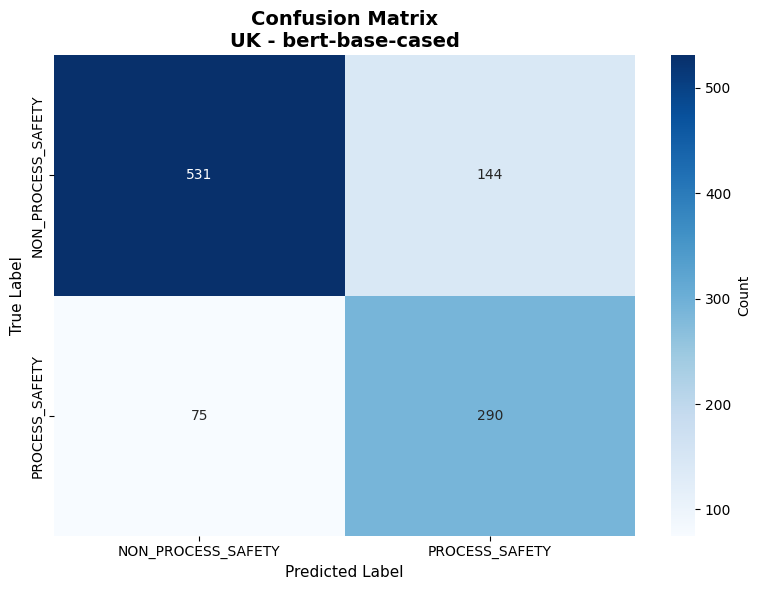


Training SVM: GERMANY | Model: bert-base-cased
Training samples: 14634
Test samples: 3659

Training LinearSVC (max 300s)...
Training completed in 4.63s

Accuracy: 0.7822
F1 Score (weighted): 0.8113
F1 Score (macro): 0.6696

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9535    0.7873    0.8625      3174
    Process Safety     0.3497    0.7485    0.4767       485

          accuracy                         0.7822      3659
         macro avg     0.6516    0.7679    0.6696      3659
      weighted avg     0.8734    0.7822    0.8113      3659


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_germany_bert_base_cased.png


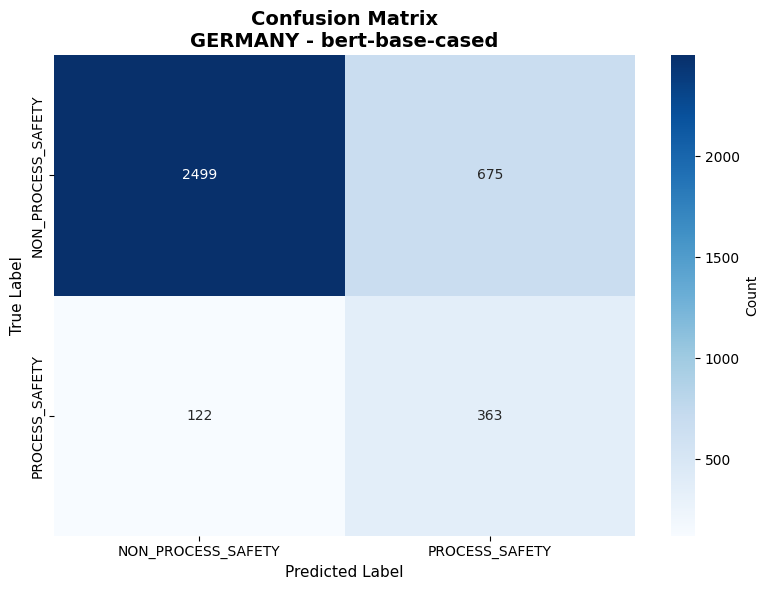


Training SVM: SWEDEN | Model: bert-base-cased
Training samples: 16181
Test samples: 4046

Training LinearSVC (max 300s)...
Training completed in 5.78s

Accuracy: 0.7870
F1 Score (weighted): 0.8356
F1 Score (macro): 0.5911

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9730    0.7934    0.8741      3771
    Process Safety     0.1977    0.6982    0.3082       275

          accuracy                         0.7870      4046
         macro avg     0.5854    0.7458    0.5911      4046
      weighted avg     0.9203    0.7870    0.8356      4046


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_sweden_bert_base_cased.png


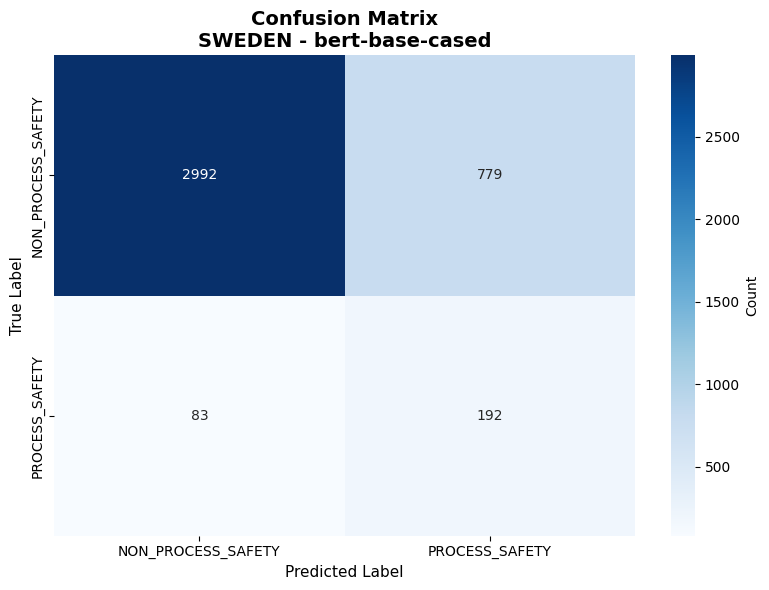


Training SVM: ENGLISH | Model: bert-base-cased
Training samples: 4198
Test samples: 1050

Training LinearSVC (max 300s)...
Training completed in 1.00s

Accuracy: 0.7752
F1 Score (weighted): 0.7790
F1 Score (macro): 0.7643

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8681    0.7681    0.8150       677
    Process Safety     0.6519    0.7882    0.7136       373

          accuracy                         0.7752      1050
         macro avg     0.7600    0.7781    0.7643      1050
      weighted avg     0.7913    0.7752    0.7790      1050


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_english_bert_base_cased.png


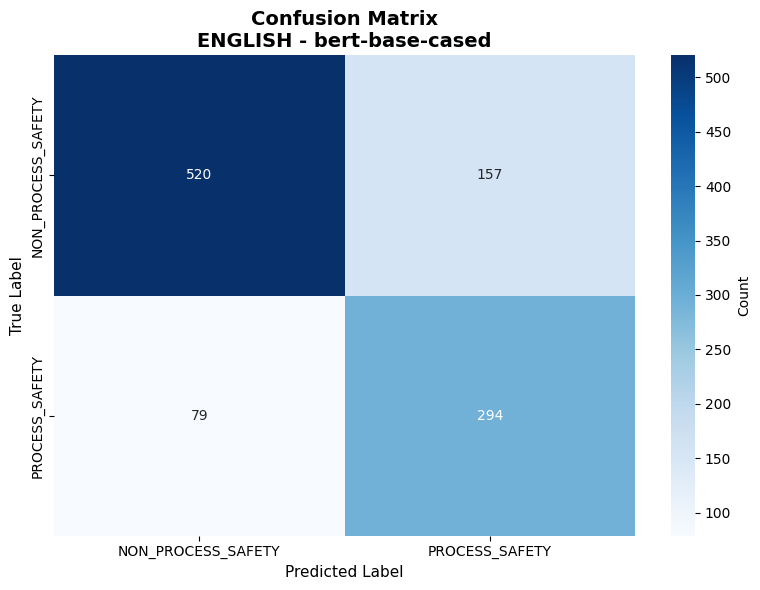


Training SVM: NETHERLANDS | Model: bert-base-cased
Training samples: 2048
Test samples: 512

Training LinearSVC (max 300s)...
Training completed in 0.45s

Accuracy: 0.7559
F1 Score (weighted): 0.7586
F1 Score (macro): 0.7382

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8333    0.7808    0.8062       333
    Process Safety     0.6350    0.7095    0.6702       179

          accuracy                         0.7559       512
         macro avg     0.7342    0.7451    0.7382       512
      weighted avg     0.7640    0.7559    0.7586       512


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_netherlands_bert_base_cased.png


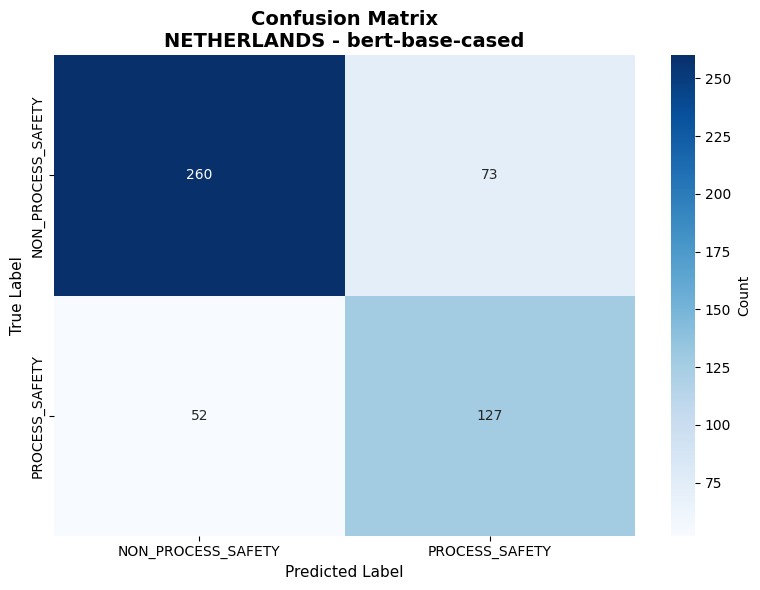


 Processing complete bert-base-cased

################################################################################
MODEL: bert-large-cased (bert-large-cased)
################################################################################

Initializing bert-large-cased...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-large-cased

Processing: uk | Model: bert-large-cased
Dataset shape: (5196, 36)

Case type distribution:
CASE_TYPE
Safety                              2335
Process Safety                      1822
Environment                          588
Asset and Reputation damage/loss     213
Operational loss                     181
Information Security                  20
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1299/1299 [10:10<00:00,  2.13it/s]
/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_16470/2069368892.py:125: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)



Training set: (4156, 1024)
Test set: (1040, 1024)

Class distribution in training set:
binary_label
0    64.94%
1    35.06%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-large-cased/uk_bert-large-cased_embeddings.pkl
Size: 22.06 MB

Checkpoint saved. Progress: 6/30

Processing: germany | Model: bert-large-cased
Dataset shape: (18293, 36)

Case type distribution:
CASE_TYPE
Safety                              13012
Process Safety                       2424
Environment                          1459
Asset and Reputation damage/loss      918
Information Security                  250
Operational loss                       93
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 4574/4574 [41:05<00:00,  1.86it/s]  



Training set: (14634, 1024)
Test set: (3659, 1024)

Class distribution in training set:
binary_label
0    86.75%
1    13.25%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_2/bert-large-cased/germany_bert-large-cased_embeddings.pkl
Size: 75.91 MB

Checkpoint saved. Progress: 7/30

Processing: sweden | Model: bert-large-cased
Dataset shape: (20227, 36)

Case type distribution:
CASE_TYPE
Safety                              16572
Process Safety                       1374
Environment                           990
Asset and Reputation damage/loss      860
Operational loss                      430
Information Security                    1
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings:  80%|███████▉  | 4045/5057 [18:49<04:29,  3.75it/s]  

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
from multiprocessing import Process, Queue
import signal

# ============================================================
# Configuration
# ============================================================

# Use PATHS from earlier configuration (already cross-platform)
DATA_DIR = str(PATHS['by_country'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['iteration_output'] / "checkpoint.json")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations
MODELS = {
    'bert-base-cased': 'bert-base-cased',
    'bert-large-cased': 'bert-large-cased',
    'roberta-base': 'roberta-base',
    'roberta-large': 'roberta-large',
    'distilbert-base-cased': 'distilbert-base-cased',
    'xlnet-base-cased': 'xlnet-base-cased'
}

# Datasets to skip
SKIP_DATASETS = [
    'RW_ACTUALS_Hungary.csv',
    'RW_ACTUALS_International.csv',
    'RW_ACTUALS_Russia.csv',
    'RW_ACTUALS_UAE.csv'
]

# Timeout and memory management settings
MAX_PROCESSING_TIME = 3600 * 3  # 3 hours in seconds
BATCH_SIZE = 4  # Reduce to prevent memory issues
SVM_TIMEOUT = 300  # 5 minutes timeout for SVM training
MAX_SAMPLES_SVM = 60000  # Limit samples for large datasets 

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

# ============================================================
# Functions
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=4):
    """Generate BERT embeddings for a list of texts with memory management"""
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'cuda':
            torch.cuda.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)


def process_dataset(csv_file, model_name, model_key, tokenizer, model):
    """Process a single CSV dataset and save embeddings"""
    # Extract dataset name from filename
    filename = os.path.basename(csv_file)
    dataset_name = filename.replace('RW_ACTUALS_', '').replace('.csv', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name} | Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_csv(csv_file)
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\nWARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_short_name = model_name.replace('/', '_')
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name)
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings (save both full and subset)
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_short_name}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory after processing
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file


def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_name = metadata['model']
    model_key = metadata.get('model_key', model_name)
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    # Use faster LinearSVC instead of SVC with timeout protection
    try:
        from sklearn.svm import LinearSVC
        from sklearn.metrics import precision_recall_fscore_support
        
        print(f"\nTraining LinearSVC (max {SVM_TIMEOUT}s)...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        # Create safe filename
        model_short = model_name.replace('/', '_').replace('-', '_')
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'cm_{dataset_name}_{model_short}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\nConfusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': model_name,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            # Non-Process Safety (class 0) metrics
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            # Process Safety (class 1) metrics
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\nERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise


# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)

# Get all CSV files and filter out skipped datasets
all_csv_files = glob.glob(os.path.join(DATA_DIR, 'RW_ACTUALS_*.csv'))
csv_files = [f for f in all_csv_files if os.path.basename(f) not in SKIP_DATASETS]

print(f"\nFound {len(all_csv_files)} total datasets")
print(f"Skipping {len(SKIP_DATASETS)} datasets:")
for skip in SKIP_DATASETS:
    print(f" {skip}")
print(f"\nProcessing {len(csv_files)} datasets")
print(f"Found {len(MODELS)} models to use")
print(f"Total combinations: {len(csv_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"Already processed: {len(processed_items)} combinations")

# Track all results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        print(f"Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for csv_file in csv_files:
            dataset_name = os.path.basename(csv_file).replace('RW_ACTUALS_', '').replace('.csv', '').lower()
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\nSkipping already processed: {dataset_name} with {model_key}")
                model_short_name = model_name.replace('/', '_')
                pkl_file = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name, 
                                       f'{dataset_name}_{model_short_name}_embeddings.pkl')
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            # Check timeout
            elapsed_time = time.time() - start_time
            if elapsed_time > MAX_PROCESSING_TIME:
                print(f"\nReached time limit ({MAX_PROCESSING_TIME/60:.1f} minutes).")
                print(f"Resume by running this cell again - checkpoint saved.")
                break
            
            try:
                pkl_file = process_dataset(csv_file, model_name, model_key, tokenizer, model)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Checkpoint saved. Progress: {len(processed_items)}/{len(csv_files) * len(MODELS)}")
                
            except Exception as e:
                print(f"✗ ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f"ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n Processing complete {model_key}")
        
    except Exception as e:
        print(f"\nERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display DETAILED results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    # Format the detailed table
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps'
    ]
    
    # Check which columns exist
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    
    if 'training_time' in results_df.columns:
        display_cols.append('training_time')
    if 'subsampled' in results_df.columns:
        display_cols.append('subsampled')
    
    # Create a formatted display DataFrame
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns for better display
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save detailed results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'all_models_svm_detailed_results.csv')
    results_df.to_csv(summary_file, index=False)
    print(f"\nDetailed results saved to: {summary_file}")
    
    # Create a formatted classification report style table
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING MODEL (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best by F1 for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Results by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Results by dataset
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY DATASET")
        print(f"{'='*80}")
        dataset_stats = results_df.groupby('dataset')[['accuracy', 'f1_weighted', 'f1_macro',
                                                         'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(dataset_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(csv_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print("ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print("PIPELINE COMPLETE")
print("#"*80)